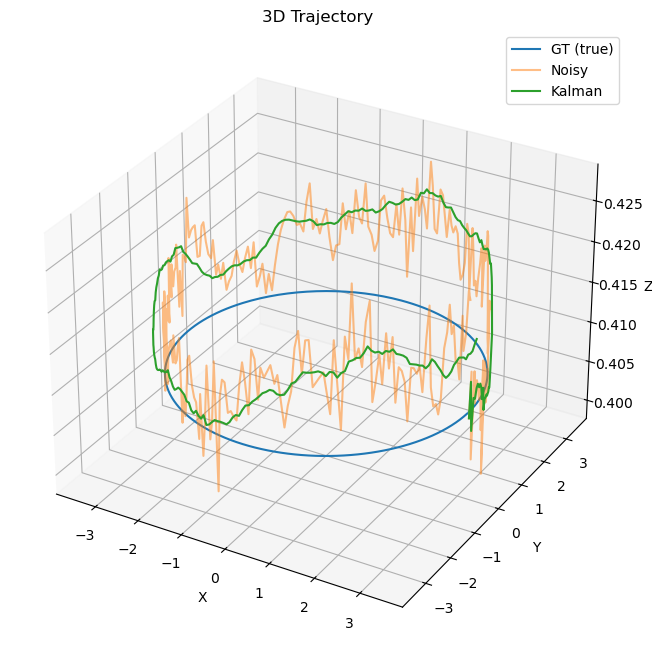

RMSE: 0.211263 m
MAE: 0.202550 m
Max error: 0.236305 m


In [40]:
import json
import numpy as np
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


files = sorted(glob.glob("/home/konssta/perseption/FP/data/coords/frame_*.json"))

gt_positions = []
noisy_positions = []

for f in files:
    with open(f) as fp:
        data = json.load(fp)

        gt = data["camera_gt"]["position_world_m"]
        noisy = data["camera_noisy"]["position_world_m"]

        gt_positions.append([gt["x"], gt["y"], gt["z"]])
        noisy_positions.append([noisy["x"], noisy["y"], noisy["z"]])

gt_positions = np.array(gt_positions)
noisy_positions = np.array(noisy_positions)

#KF

dt = 1.0

A = np.block([
    [np.eye(3), dt * np.eye(3)],
    [np.zeros((3, 3)), np.eye(3)]
])

H = np.block([
    [np.eye(3), np.zeros((3, 3))]
])

Q = 1e-5 * np.eye(6)
R = 0.3 * np.eye(3)

x = np.zeros(6)
x[:3] = noisy_positions[0]

P = np.eye(6)

kf_positions = []

for z in noisy_positions:
    z = np.array(z)

    # Prediction
    x_pred = A @ x
    P_pred = A @ P @ A.T + Q

    # Update
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)

    x = x_pred + K @ y
    P = (np.eye(6) - K @ H) @ P_pred

    kf_positions.append(x[:3])

kf_positions = np.array(kf_positions)



fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    gt_positions[:, 0],
    gt_positions[:, 1],
    gt_positions[:, 2],
    label="GT (true)"
)

ax.plot(
    noisy_positions[:, 0],
    noisy_positions[:, 1],
    noisy_positions[:, 2],
    label="Noisy",
    alpha=0.5
)

ax.plot(
    kf_positions[:, 0],
    kf_positions[:, 1],
    kf_positions[:, 2],
    label="Kalman"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Trajectory")

ax.legend()
plt.show()


from scipy.signal import savgol_filter

kf_positions_smooth = savgol_filter(kf_positions, window_length=21, polyorder=3, axis=0)

diff = kf_positions_smooth - gt_positions


errors = np.linalg.norm(diff, axis=1)


rmse = np.sqrt(np.mean(errors**2))
mae = np.mean(errors)
max_error = np.max(errors)

print(f"RMSE: {rmse:.6f} m")
print(f"MAE: {mae:.6f} m")
print(f"Max error: {max_error:.6f} m")

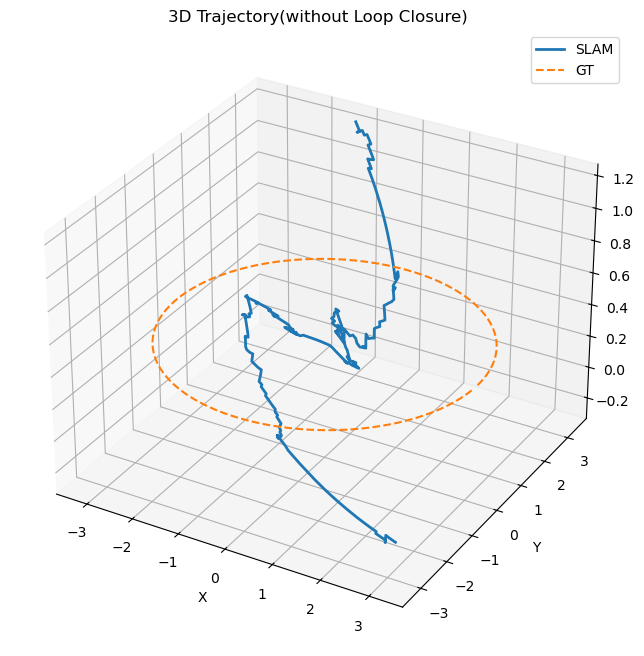

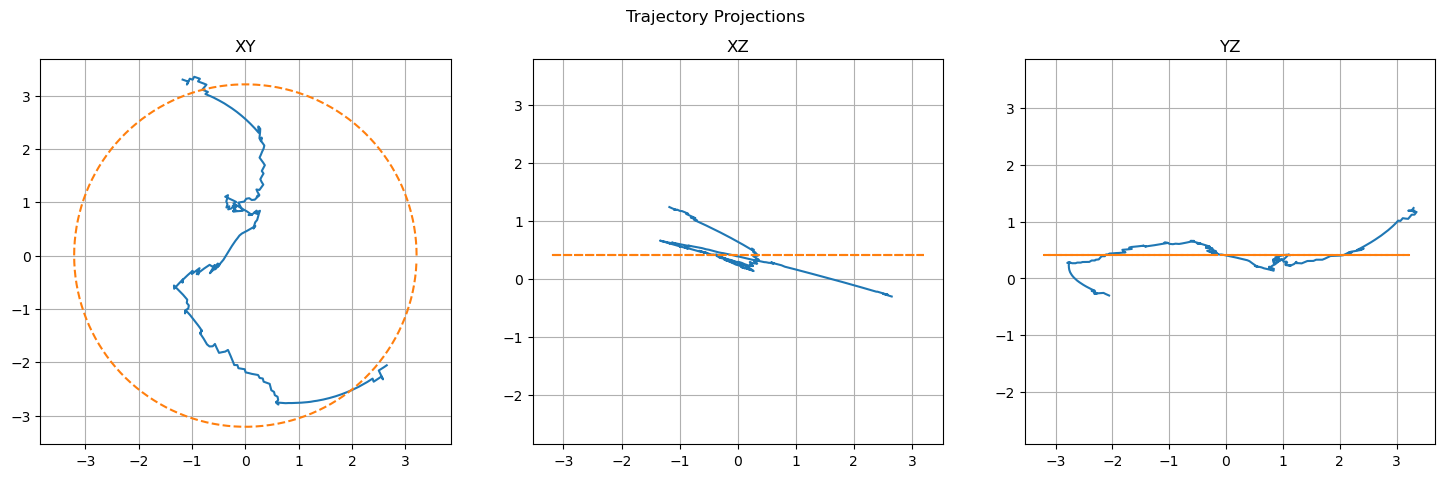

In [41]:
import numpy as np
import pandas as pd
import json
import gtsam
from gtsam import Pose3, Rot3, Point3, symbol
import matplotlib.pyplot as plt



df = pd.read_csv('data/poses.csv')

with open('data/orbit_summary.json') as f:
    orbit = json.load(f)

# GT 

gt_positions = []
for fdata in orbit["frames"]:
    gt = fdata["camera_gt_xyz"]
    gt_positions.append([gt["x"], gt["y"], gt["z"]])
gt_positions = np.array(gt_positions)


graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

odom_noise = gtsam.noiseModel.Diagonal.Sigmas(np.ones(6) * 0.05)


x0 = symbol('x', 0)
graph.add(gtsam.PriorFactorPose3(
    x0, Pose3(),
    gtsam.noiseModel.Diagonal.Sigmas(np.ones(6)*1e-6)
))
initial.insert(x0, Pose3())


poses = [Pose3()]

for i, row in df.iterrows():
    if i == 0:
        continue

    xi = symbol('x', i)
    xi_prev = symbol('x', i-1)

    R = row[['r11','r12','r13',
             'r21','r22','r23',
             'r31','r32','r33']].values.reshape(3,3)

    t = np.array([row['tx'], row['ty'], row['tz']])

    pose = Pose3(Rot3(R), Point3(*t))

    graph.add(gtsam.BetweenFactorPose3(
        xi_prev, xi, pose, odom_noise
    ))

    new_pose = poses[-1].compose(pose)
    poses.append(new_pose)
    initial.insert(xi, new_pose)



last_idx = len(df) - 1

loop_noise = gtsam.noiseModel.Diagonal.Sigmas(np.ones(6) * 0.01)

# graph.add(gtsam.BetweenFactorPose3(
#     symbol('x', last_idx),
#     symbol('x', 0),
#     Pose3(),
#     loop_noise
# ))


optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()


trajectory = []

for i in range(len(df)):
    pose = result.atPose3(symbol('x', i))
    trajectory.append(pose.translation())

trajectory = np.array(trajectory)


def umeyama_alignment(X, Y, with_scale=True):
    assert X.shape == Y.shape

    n = X.shape[0]

    mean_X = X.mean(axis=0)
    mean_Y = Y.mean(axis=0)

    Xc = X - mean_X
    Yc = Y - mean_Y

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[2, 2] = -1

    R = U @ S @ Vt

    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        scale = np.trace(np.diag(D) @ S) / var_X
    else:
        scale = 1.0

    t = mean_Y - scale * R @ mean_X

    return scale, R, t


min_len = min(len(trajectory), len(gt_positions))
traj = trajectory[:min_len]
gt = gt_positions[:min_len]

s, R, t = umeyama_alignment(traj, gt, True)

trajectory_aligned = (s * (R @ traj.T)).T + t
gt_aligned = gt


#3D plot


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(*trajectory_aligned.T, label="SLAM", linewidth=2)
ax.plot(*gt_aligned.T, '--', label="GT")

ax.set_title("3D Trajectory(without Loop Closure)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()



fig, axs = plt.subplots(1, 3, figsize=(18,5))

# XY
axs[0].plot(trajectory_aligned[:,0], trajectory_aligned[:,1])
axs[0].plot(gt_aligned[:,0], gt_aligned[:,1], '--')
axs[0].set_title("XY")
axs[0].axis('equal')
axs[0].grid()

# XZ
axs[1].plot(trajectory_aligned[:,0], trajectory_aligned[:,2])
axs[1].plot(gt_aligned[:,0], gt_aligned[:,2], '--')
axs[1].set_title("XZ")
axs[1].axis('equal')
axs[1].grid()

# YZ
axs[2].plot(trajectory_aligned[:,1], trajectory_aligned[:,2])
axs[2].plot(gt_aligned[:,1], gt_aligned[:,2], '--')
axs[2].set_title("YZ")
axs[2].axis('equal')
axs[2].grid()

plt.suptitle("Trajectory Projections")
plt.show()


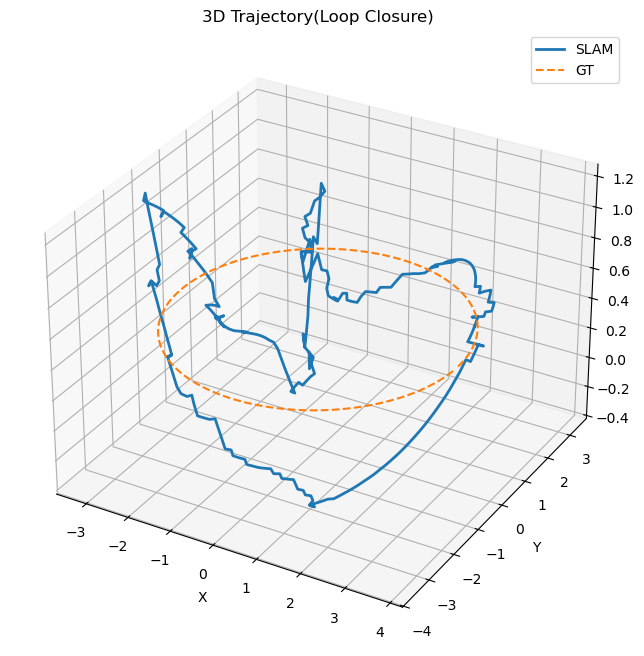

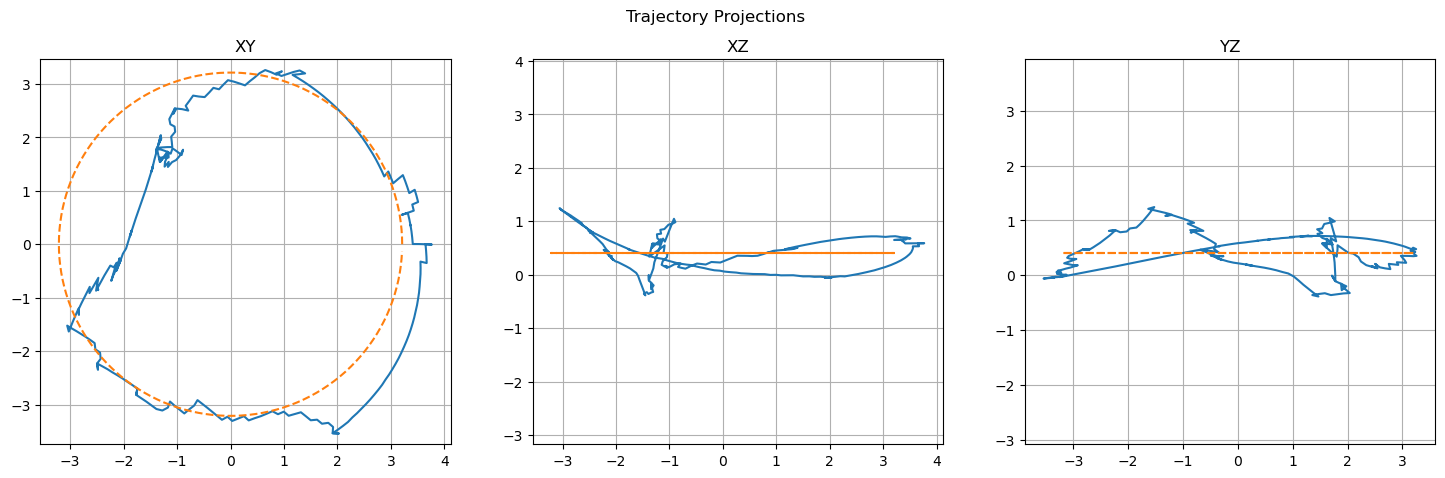

In [42]:
import numpy as np
import pandas as pd
import json
import gtsam
from gtsam import Pose3, Rot3, Point3, symbol
import matplotlib.pyplot as plt



df = pd.read_csv('data/poses.csv')

with open('data/orbit_summary.json') as f:
    orbit = json.load(f)

# GT 

gt_positions = []
for fdata in orbit["frames"]:
    gt = fdata["camera_gt_xyz"]
    gt_positions.append([gt["x"], gt["y"], gt["z"]])
gt_positions = np.array(gt_positions)


graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()

odom_noise = gtsam.noiseModel.Diagonal.Sigmas(np.ones(6) * 0.05)


x0 = symbol('x', 0)
graph.add(gtsam.PriorFactorPose3(
    x0, Pose3(),
    gtsam.noiseModel.Diagonal.Sigmas(np.ones(6)*1e-6)
))
initial.insert(x0, Pose3())


poses = [Pose3()]

for i, row in df.iterrows():
    if i == 0:
        continue

    xi = symbol('x', i)
    xi_prev = symbol('x', i-1)

    R = row[['r11','r12','r13',
             'r21','r22','r23',
             'r31','r32','r33']].values.reshape(3,3)

    t = np.array([row['tx'], row['ty'], row['tz']])

    pose = Pose3(Rot3(R), Point3(*t))

    graph.add(gtsam.BetweenFactorPose3(
        xi_prev, xi, pose, odom_noise
    ))

    new_pose = poses[-1].compose(pose)
    poses.append(new_pose)
    initial.insert(xi, new_pose)



last_idx = len(df) - 1

loop_noise = gtsam.noiseModel.Diagonal.Sigmas(np.ones(6) * 0.01)

graph.add(gtsam.BetweenFactorPose3(
    symbol('x', last_idx),
    symbol('x', 0),
    Pose3(),
    loop_noise
))


optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial)
result = optimizer.optimize()


trajectory = []

for i in range(len(df)):
    pose = result.atPose3(symbol('x', i))
    trajectory.append(pose.translation())

trajectory = np.array(trajectory)


def umeyama_alignment(X, Y, with_scale=True):
    assert X.shape == Y.shape

    n = X.shape[0]

    mean_X = X.mean(axis=0)
    mean_Y = Y.mean(axis=0)

    Xc = X - mean_X
    Yc = Y - mean_Y

    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)

    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[2, 2] = -1

    R = U @ S @ Vt

    if with_scale:
        var_X = np.mean(np.sum(Xc**2, axis=1))
        scale = np.trace(np.diag(D) @ S) / var_X
    else:
        scale = 1.0

    t = mean_Y - scale * R @ mean_X

    return scale, R, t


min_len = min(len(trajectory), len(gt_positions))
traj = trajectory[:min_len]
gt = gt_positions[:min_len]

s, R, t = umeyama_alignment(traj, gt, True)

trajectory_aligned = (s * (R @ traj.T)).T + t
gt_aligned = gt


#3D plot


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(*trajectory_aligned.T, label="SLAM", linewidth=2)
ax.plot(*gt_aligned.T, '--', label="GT")

ax.set_title("3D Trajectory(Loop Closure)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()



fig, axs = plt.subplots(1, 3, figsize=(18,5))

# XY
axs[0].plot(trajectory_aligned[:,0], trajectory_aligned[:,1])
axs[0].plot(gt_aligned[:,0], gt_aligned[:,1], '--')
axs[0].set_title("XY")
axs[0].axis('equal')
axs[0].grid()

# XZ
axs[1].plot(trajectory_aligned[:,0], trajectory_aligned[:,2])
axs[1].plot(gt_aligned[:,0], gt_aligned[:,2], '--')
axs[1].set_title("XZ")
axs[1].axis('equal')
axs[1].grid()

# YZ
axs[2].plot(trajectory_aligned[:,1], trajectory_aligned[:,2])
axs[2].plot(gt_aligned[:,1], gt_aligned[:,2], '--')
axs[2].set_title("YZ")
axs[2].axis('equal')
axs[2].grid()

plt.suptitle("Trajectory Projections")
plt.show()



In [43]:
errors_xyz = trajectory_aligned - gt_aligned

errors = np.linalg.norm(errors_xyz, axis=1)

rmse = np.sqrt(np.mean(errors**2))
mae = np.mean(errors)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 1.0937
MAE:  1.0326


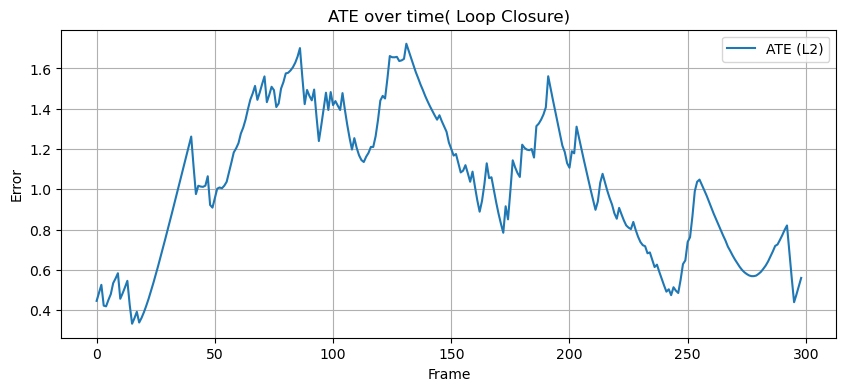

In [44]:
plt.figure(figsize=(10,4))
plt.plot(errors, label="ATE (L2)")
plt.xlabel("Frame")
plt.ylabel("Error")
plt.title("ATE over time( Loop Closure)")
plt.grid()
plt.legend()
plt.show()

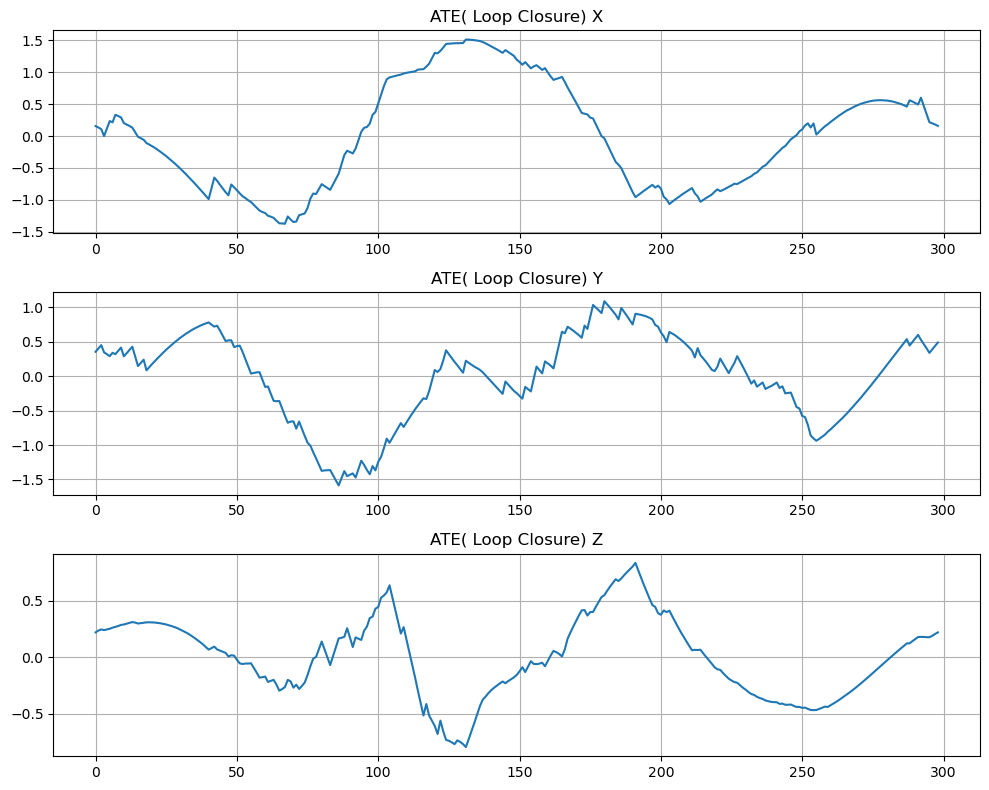

In [45]:
fig, axs = plt.subplots(3, 1, figsize=(10,8))

labels = ['X', 'Y', 'Z']

for i in range(3):
    axs[i].plot(errors_xyz[:, i])
    axs[i].set_title(f"ATE( Loop Closure) {labels[i]}")
    axs[i].grid()

plt.tight_layout()
plt.show()